# Plantilla base


In [ ]:
import findspark
findspark.init("/usr/local/spark-3.5.0-bin-hadoop3")

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, rand, isnull, isnotnull, avg, count, min, max, explode

spark = SparkSession.builder.getOrCreate()

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("work/netflix_titles.csv")
)

# 1. Renombrar listed_in a genero
df1 = df.withColumnRenamed("listed_in", "genero")

# 2. Convertir cast en array de personas
df2 = df1.withColumn("cast", split(col("cast"), ", "))

# 3. Extraer un 20% aleatorio y mostrarlo
df3 = df2.sample(withReplacement=False, fraction=0.2, seed=42)
df3.show(truncate=False)

# 4. 10 películas más antiguas eliminando nulos con isnull/isnotnull
df4 = df2.filter(
    isnotnull(col("type")) &
    isnotnull(col("release_year")) &
    isnotnull(col("title")) &
    (col("type") == "Movie")
).orderBy(col("release_year").asc()).limit(10)
df4.show(truncate=False)

# 5. 10 películas más antiguas eliminando nulos con dropna
df5 = (
    df2.dropna(subset=["type", "release_year", "title"])
       .filter(col("type") == "Movie")
       .orderBy(col("release_year").asc())
       .limit(10)
)
df5.show(truncate=False)

# 6. Títulos con alias NOMBRE, 10 primeras películas ordenadas alfabéticamente
df6 = (
    df2.filter(col("type") == "Movie")
       .select(col("title").alias("NOMBRE"))
       .orderBy(col("NOMBRE").asc())
       .limit(10)
)
df6.show(truncate=False)

# 7. Contar filas donde director sea NULL
df7 = df2.filter(isnull(col("director"))).count()
print("Filas con director NULL:", df7)

# 8. Eliminar filas con nulos en rating
df8 = df2.dropna(subset=["rating"])
df8.show(truncate=False)

# 9. Rellenar nulos de director con Desconocido
df9 = df2.fillna({"director": "Desconocido"})
df9.show(truncate=False)

# 10. Reemplazar NR y UR por Sin clasificación
df10 = df9.replace(["NR", "UR"], "Sin clasificación", subset=["rating"])
df10.select("rating").distinct().show(truncate=False)

# 11. Año medio de estreno de las películas
df11 = df10.filter(col("type") == "Movie").select(avg("release_year").alias("anio_medio"))
df11.show()

    # 12. Cuenta de publicaciones por tipo de contenido
    df12 = df10.groupBy("type").count()
    df12.show()

# 13. Año más antiguo, más reciente y promedio con agg
df13 = df10.filter(col("type") == "Movie").agg(
    min("release_year").alias("anio_mas_antiguo"),
    max("release_year").alias("anio_mas_reciente"),
    avg("release_year").alias("anio_promedio")
)
df13.show()

# 14. Pivote: tipos de contenido por clasificación
df14 = df10.groupBy("rating").pivot("type").count()
df14.show()

# 15. Explode: persona que aparece en más contenidos
df15 = (
    df10.select(explode(col("cast")).alias("persona"))
       .groupBy("persona")
       .count()
       .orderBy(col("count").desc())
       .limit(1)
)
df15.show(truncate=False)

# 16. Guardar en parquet el resultado del apartado 12
df12.write.mode("overwrite").parquet("work/netflix_tipo_contenido_parquet")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.DataFrame({ # Crea un DataFrame de pandas a partir de un diccionario
    "Nombre": ["Ana","Luis","Pedro"],
    "Edad": [20,25,30]
})
# df = pd.read_csv("datos.csv")

# Exploración inicial
print(df.head())
print(df.info())
print(df.describe())

# Limpieza
df = df.dropna()

# o sustituir nulos por media por ej
df = df.fillna(df.mean())

# Ejercicio 1
# ...

# Ejercicio 2
# ...

  Nombre  Edad
0    Ana    20
1   Luis    25
2  Pedro    30
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Nombre  3 non-null      str  
 1   Edad    3 non-null      int64
dtypes: int64(1), str(1)
memory usage: 180.0 bytes
None
       Edad
count   3.0
mean   25.0
std     5.0
min    20.0
25%    22.5
50%    25.0
75%    27.5
max    30.0


# 1. Numpy


In [13]:
import numpy as np
# Crear arrays
a = np.array([1,2,3])
b = np.array([[1,2],[3,4]])

np.zeros((3,4)) # Crea un array de ceros de tamaño 3x4
np.ones((2,2)) # Crea un array de unos de tamaño 2x2
np.full((3,3), 7) # Crea un array de tamaño 3x3 lleno con el valor 7

np.arange(0,10,2) # Crea un array con valores desde 0 hasta 10 (exclusivo) con un paso de 2
np.linspace(0,1,5) # Crea un array con 5 valores igualmente espaciados entre 0 y 1

np.random.rand(3,3) # Crea un array de tamaño 3x3 con valores aleatorios entre 0 y 1
np.random.randint(0,10,(3,3)) # Crea un array de tamaño 3x3 con valores enteros aleatorios entre 0 y 10 (exclusivo)

array([[0, 9, 3],
       [2, 0, 3],
       [6, 4, 0]], dtype=int32)

In [15]:
# PROPIEDADES
a.shape # Devuelve la forma del array (número de filas y columnas)
a.ndim # Devuelve el número de dimensiones del array
a.size # Devuelve el número total de elementos en el array
a.dtype # Devuelve el tipo de datos de los elementos en el array
# a.reshape(2,3) # Cambia la forma del array a 2 filas y 3 columnas
a.flatten() # Devuelve una copia del array aplanado (1D)
a.T # Devuelve la transpuesta del array (intercambia filas por columnas)

array([1, 2, 3])

In [ ]:
# INDEX Y SLICING
a[0]
a[1:4]
a[a > 5]   # filtrado booleano

array([], dtype=int64)

In [20]:
# ESTADISTICAS BASICAS
np.mean(a)
np.median(a)
np.std(a) # Desviación estándar
np.var(a) # Varianza
np.min(a)
np.max(a)
np.sum(a)
np.argmin(a) # Devuelve el INDICE del valor mínimo en el array
np.argmax(a) # Devuelve el INDICE del valor máximo en el array

#Ej:
np.sum(a, axis=0) # Suma a lo largo de las columnas (axis=0)
# np.mean(a, axis=1) # Promedio a lo largo de las filas (axis=1)


np.int64(6)

# **PANDAS**

In [22]:
import pandas as pd
s = pd.Series([1,2,3]) # Crea una Serie de pandas a partir de una lista

df = pd.DataFrame({ # Crea un DataFrame de pandas a partir de un diccionario
    "Nombre": ["Ana","Luis","Pedro"],
    "Edad": [20,25,30]
})

# CARGAR DATOS
#  df = pd.read_csv("")
#  df = pd.read_excel("")

# Exploracion inicial:
df.head()
df.tail()
df.info()
df.describe()
print('a')
print(f'shape: {df.shape}') # Devuelve una tupla con el número de filas y columnas del DataFrame
print(f'columns: {df.columns}') # Devuelve un índice con los nombres de las columnas del DataFrame
print(f'dtypes: {df.dtypes}') # Devuelve una Serie con los tipos de datos de cada columna del DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Nombre  3 non-null      str  
 1   Edad    3 non-null      int64
dtypes: int64(1), str(1)
memory usage: 180.0 bytes
a
shape: (3, 2)
columns: Index(['Nombre', 'Edad'], dtype='str')
dtypes: Nombre      str
Edad      int64
dtype: object


In [23]:
# Acceso por columnas
df["Edad"]
df[["Nombre","Edad"]]

# LOC: Acceso por etiquetas
df.loc[0] # Accede a la fila con etiqueta 0 (primera fila)
df.loc[0,"Edad"] # Accede al valor de la columna "Edad" en la fila con etiqueta 0

# ILOC: Acceso por posición
df.iloc[0]
df.iloc[0,1]

# FILTRADO
df[df["Edad"] > 25] # Filtra las filas donde la columna "Edad" es mayor a 25

df[(df["Edad"] > 20) & (df["Edad"] < 30)] # Filtra las filas donde la columna "Edad" es mayor a 20 y menor a 30
df[(df["Edad"] > 20) | (df["Nombre"] == "Ana")] # Filtra las filas donde la columna "Edad" es mayor a 20 o el nombre es "Ana"

,Nombre,Edad
0,Ana,20
1,Luis,25
2,Pedro,30


In [26]:
df["Nueva"] = df["Edad"] * 2

df["Categoria"] = np.where(df["Edad"] > 25, "Mayor", "Joven")

# Ordenar
df.sort_values("Edad")
df.sort_values("Edad", ascending=False)

# Agrupar
df.groupby("Categoria")["Edad"].mean()
# df.groupby("Categoria").mean()
# Agrupa por "Categoria" y calcula la media, suma y máximo de las columnas numéricas para cada grupo
# df.groupby("Categoria").agg(["mean","sum","max"]) 

# NULOS
df.isnull() # Devuelve un DataFrame booleano indicando dónde hay valores nulos
df.isnull().sum() # Devuelve una Serie con el conteo de valores nulos por columna

df.dropna() # Elimina las filas que contienen al menos un valor nulo
df.fillna(0) # Rellena los valores nulos con 0 (puedes usar otros valores o métodos como 'ffill' o 'bfill')

# EJ: Sustituir valores nulos por media de la columna
df["Edad"].fillna(df["Edad"].mean(), inplace=True)


C:\Users\alvar\AppData\Local\Temp\ipykernel_44732\503157070.py:23: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Edad"].fillna(df["Edad"].mean(), inplace=True)


0    20
1    25
2    30
Name: Edad, dtype: int64

# **MATPLOTLIB**

In [27]:
import matplotlib.pyplot as plt

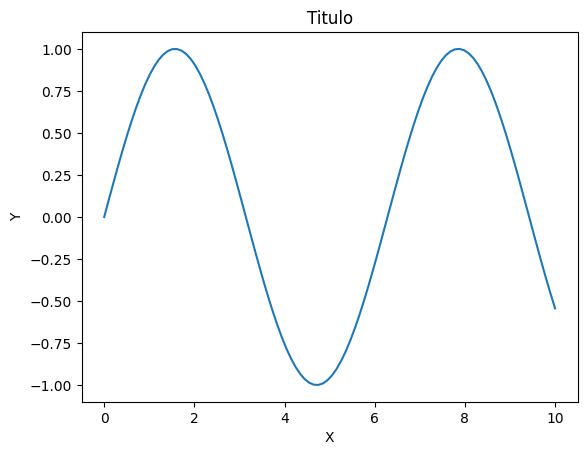

In [28]:
#GRAFICOS DE LINEAS
x = np.linspace(0,10,100)
y = np.sin(x)
plt.plot(x, y)
plt.title("Titulo")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

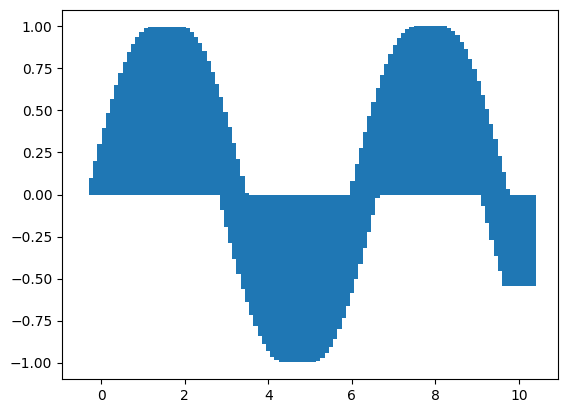

In [29]:
# BARRAS
plt.bar(x, y)
plt.show()

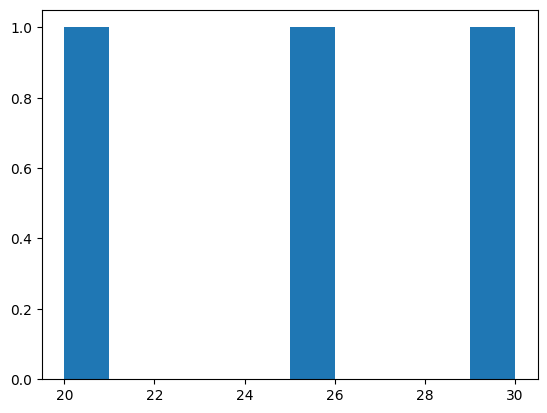

In [30]:
# HISTOGRAMA
plt.hist(df["Edad"], bins=10)
plt.show()

# **EJ 1:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datos.csv")

# Revisar
print(df.head())      # primeras filas
print(df.info())      # tipos y nulos
print(df.describe())  # estadísticas
print(df.isnull().sum())  # contar nulos por columna

df.isna()
df.isna().sum() # contar nulos por columna

df.fillna(df.mean(numeric_only=True), inplace=True)

# Histograma de una columna numérica
plt.hist(df["Edad"], bins=10) # bins: número de barras
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Grafico de barras
df["Categoria"].value_counts().plot(kind="bar")
plt.title("Frecuencia por categoria")
plt.show()

# Scatter
plt.scatter(df["Edad"], df["Salario"])
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.title("Edad vs Salario")
plt.show()

# Guardar el dataframe en un csv nuevo
df.to_csv("datos_limpios.csv", index=False)